In [15]:
from astroquery.jplhorizons import Horizons
from astropy.time import Time
from astropy.table import vstack
import astropy.units as u
import numpy as np
import pandas as pd
import seaborn as sns

In [16]:



# Center of the Sun (Solar System Barycenter) is a common reference for deep space objects,
# but '500@10' (Sun-Earth L2 Lagrange point) or '500@0' (Solar System Barycenter)
# might be a more appropriate center for a non-Earth-based observation.
# We'll use the Solar System Barycenter ('@0') as a common reference.
observatory = '@jwst'

# Define a single epoch (Julian Date) for the query.
# Using the date Apophis had in the previous example: 2026-04-13 00:00:00 UT
epoch_jd = 2461153.5 


# see https://ssd.jpl.nasa.gov/horizons/manual.html#observer-table for an explanation of the columns.  I think I'm most intereted in:
# RA_rate, DEC_rate, H, V, 



In [17]:

# Define the exact character ranges based on the MPC schema
# Note: pandas uses 0-based indexing and the 'stop' value is exclusive
col_specification = [
    (0, 7),     # Designation
    (8, 13),    # H (Absolute Mag)
    (14, 19),   # G (Slope Parameter)
    (20, 25),   # Epoch
    (26, 35),   # Mean Anomaly
    (37, 46),   # Argument of Perihelion
    (48, 57),   # Longitude of Ascending Node
    (59, 68),   # Inclination
    (70, 79),   # Eccentricity
    (80, 91),   # Mean Daily Motion
    (92, 103),  # Semimajor Axis
    (105, 106), # Uncertainty (U)
    (107, 116), # Reference
    (117, 122), # Num observations
    (123, 126), # Num oppositions
    (127, 131), # First year / Arc
    (132, 136), # Last year / 'days'
    (137, 141), # r.m.s residual
    (142, 145), # Perturbers (Coarse)
    (146, 149), # Perturbers (Precise)
    (150, 160), # Computer Name
    (161, 165), # Flags (Hex)
    (166, 174), # Numerical ID
    (175, 194), # Readable Designation
    (194, 202)  # Last Observation Date
]

column_names = [
    "Designation", "H", "G", "Epoch", "Mean_Anomaly", "Arg_Perihelion", 
    "Node", "Inclination", "Eccentricity", "Mean_Motion", "Semimajor_Axis", 
    "Uncertainty", "Ref", "Obs_Count", "Opp_Count", "First_Obs", "Last_Obs_Arc",
    "RMS_Resid", "Pert_Coarse", "Pert_Precise", "Comp_Name", "Flags", "Num_ID",
    "Full_Name", "Last_Obs_Date"
]

# Read the file
# Replace 'NEA.txt' with the path to your downloaded file
df = pd.read_fwf(
    'NEA.txt', 
    colspecs=col_specification, 
    names=column_names, 
    header=None
)

# Optional: Convert numeric columns that might have been read as strings
df['H'] = pd.to_numeric(df['H'], errors='coerce')
df['Semimajor_Axis'] = pd.to_numeric(df['Semimajor_Axis'], errors='coerce')
#df[['ID', 'Name']] = df['Full_Name'].str.extract(r'(\(.*\))\s+(.*)')

# Preview the first few rows
print(df.head())

  Designation      H     G  Epoch  Mean_Anomaly  Arg_Perihelion       Node  \
0       00433  10.38  0.15  K25BL     310.55432       178.92978  304.27008   
1       00719  15.59  0.15  K25BL     240.61027       156.18940  183.86097   
2       00887  13.82  0.15  K25BL      81.54059       350.53450  110.40588   
3       01036   9.18  0.15  K25BL      97.59385       132.50313  215.44119   
4       01221  17.37  0.15  K25BL      59.87047        26.75825  171.23717   

   Inclination  Eccentricity  Mean_Motion  ...  First_Obs Last_Obs_Arc  \
0     10.82847      0.222836     0.559775  ...       1893         2025   
1     11.57311      0.546596     0.230218  ...       1911         2025   
2      9.40006      0.571170     0.253339  ...       1918         2025   
3     26.68073      0.533213     0.226551  ...       1924         2025   
4     11.86883      0.434632     0.370518  ...       1932         2025   

  RMS_Resid  Pert_Coarse  Pert_Precise  Comp_Name Flags  Num_ID Full_Name  \
0      0.

In [18]:

i=0
for row in df.itertuples():
    obj = Horizons(
        id=row.Full_Name, 
        location=observatory, 
        epochs=epoch_jd
    )
    try:
        eph2 = obj.ephemerides(quantities='1,3,9,23')
        if i>0:
            result = vstack([result,eph2])
        else:
            i=1
            result = eph2
    except ValueError:
        print(row.Full_Name)
        

result['RA_ang_rate'] = result['RA_rate'] * 15 * np.cos(np.radians(result['DEC']))
result['RA_ang_rate_sec'] = result['RA_ang_rate'].to(u.arcsec/u.second)
result['DEC_rate_sec'] = result['DEC_rate'].to(u.arcsec/u.second)
result['sky_motion'] = np.sqrt(np.square(result['DEC_rate_sec'])+np.square(result['RA_ang_rate_sec']))

print(result[:2])
result.write('asteroids.csv',format='ascii.ecsv',overwrite=True,delimiter=',')


Apollo
Ul
Wilson-Harrington
Pan
Jason
Leonard
Didymos
2008 TC3
2014 AA
2018 LA
2019 MO
2022 EB5
2022 WJ1
2023 CX1
2024 BX1
2024 RW1
2024 UQ
2024 XA1
Ati
Kamo`oalewa
     targetname            datetime_str       ...      sky_motion     
        ---                    ---            ...      arcsec / s     
-------------------- ------------------------ ... --------------------
      Kerberos (904) 2026-Apr-23 00:00:00.000 ... 0.003928348776673573
719 Albert (A911 TB) 2026-Apr-23 00:00:00.000 ...  0.13658221542690976


In [34]:
# move this bit to the previous cell prior to future runs.  This is a bit of cleanup...

#result['RA_ang_rate'] = result['RA_rate'] * np.cos(np.radians(result['DEC']))
result['RA_rate_sec'] = result['RA_rate'].to(u.arcsec/u.second)
result['DEC_rate_sec'] = result['DEC_rate'].to(u.arcsec/u.second)
result['sky_motion'] = np.sqrt(np.square(result['DEC_rate_sec'])+np.square(result['RA_rate_sec']))
result['sky_motion'] = result['sky_motion'].to(u.mas / u.second)
print(result[:2])
result.write('asteroids.csv',format='ascii.ecsv',overwrite=True,delimiter=',')

     targetname            datetime_str       ...      RA_rate_sec      
        ---                    ---            ...       arcsec / s      
-------------------- ------------------------ ... ----------------------
      Kerberos (904) 2026-Apr-23 00:00:00.000 ... 0.00028421527777777776
719 Albert (A911 TB) 2026-Apr-23 00:00:00.000 ...  -0.009100277777777778


In [35]:
df2 = result.to_pandas()
sns.set_style("whitegrid")

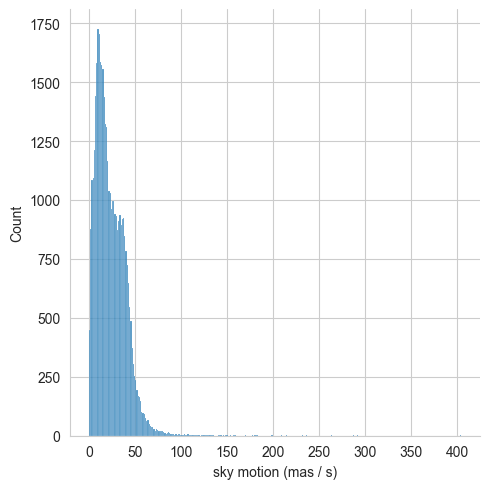

In [36]:


plt = sns.displot(data=df2,x="sky_motion")
plt.set_axis_labels(f"sky motion ({result['sky_motion'].unit})")

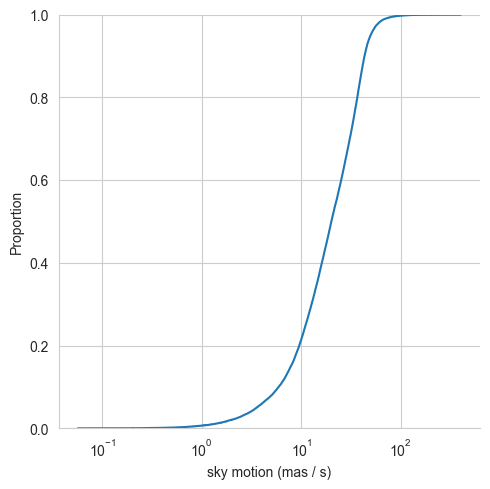

In [48]:
plt = sns.displot(data=df2,x="sky_motion", kind="ecdf", log_scale=(True))
plt.set_axis_labels(f"sky motion ({result['sky_motion'].unit})")

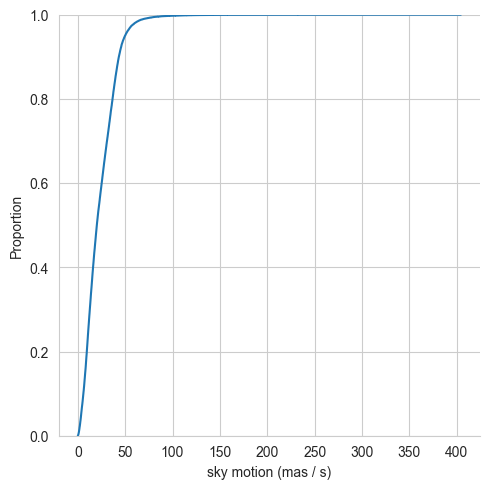

In [44]:
plt = sns.displot(data=df2,x="sky_motion", kind="ecdf")
plt.set_axis_labels(f"sky motion ({result['sky_motion'].unit})")

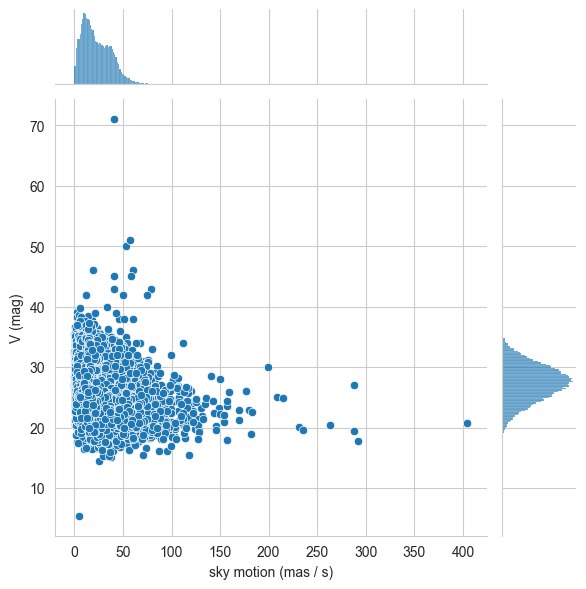

In [38]:
plt = sns.jointplot(data=df2,x="sky_motion",y="V")
plt.set_axis_labels(xlabel=f"sky motion ({result['sky_motion'].unit})",
                    ylabel=f"V ({result['V'].unit})")

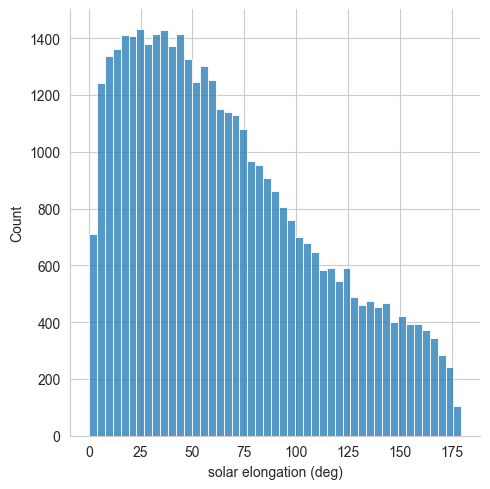

In [39]:
plt = sns.displot(data=df2, x="elong")
plt.set_axis_labels(f"solar elongation ({result['elong'].unit})")

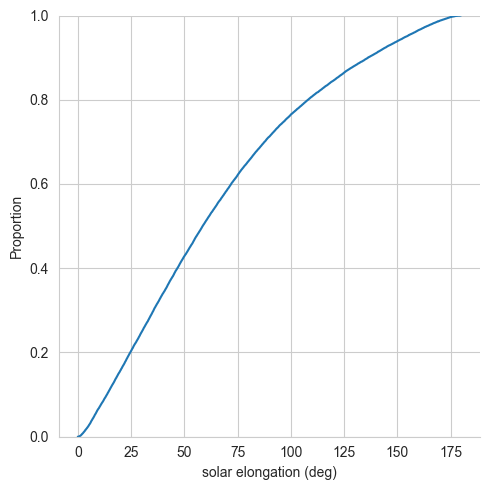

In [43]:
plt = sns.displot(data=df2,x="elong", kind="ecdf")
plt.set_axis_labels(f"solar elongation ({result['elong'].unit})")

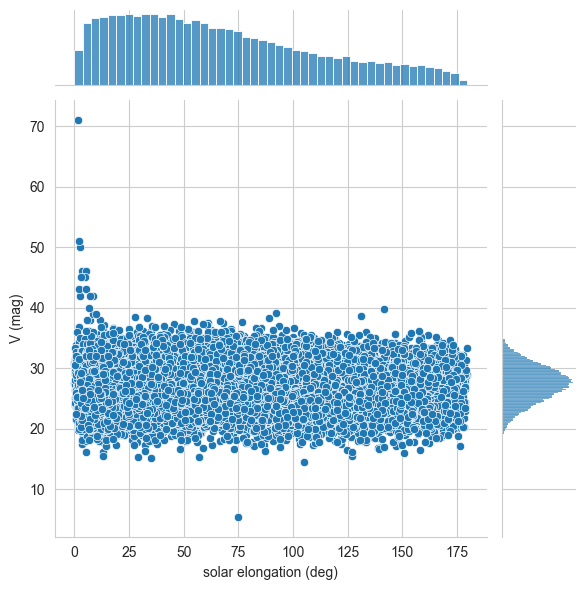

In [45]:
plt = sns.jointplot(data=df2,x="elong",y="V")
plt.set_axis_labels(xlabel=f"solar elongation ({result['elong'].unit})",
                    ylabel=f"V ({result['V'].unit})")

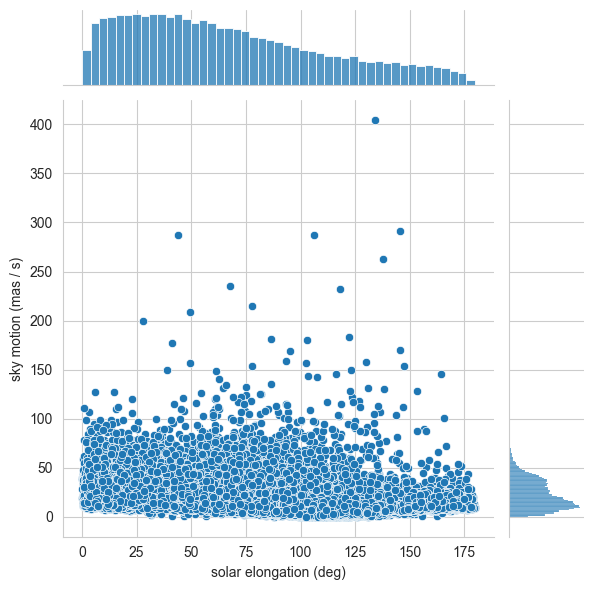

In [46]:
plt = sns.jointplot(data=df2,x="elong",y="sky_motion")
plt.set_axis_labels(xlabel=f"solar elongation ({result['elong'].unit})",
                    ylabel=f"sky motion ({result['sky_motion'].unit})")